In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_files = '../../'
hdu = fits.open(f'{path_files}en024048_hion/atmos/BIFROST_en024048_hion_lgtg_385.fits')
print(f"Length of the fits list: {len(hdu)}")
nx = 504
ny = 504
nz = 425
x_size = 24 #Mm
y_size = 24 #Mm

Length of the fits list: 2


In [3]:
def read_geometry(filename):
    # Open the file in binary read mode
    with open(filename, 'rb') as f:
        
        # --- Section 1: Dimensions ---
        # "3 integers (4 bytes) con las dimensiones de los ejes X, Y y Z"
        # We use '<i4' for little-endian 32-bit integers
        dims = np.fromfile(f, dtype='<i4', count=3)
        nx, ny, nz = dims
        
        # --- Section 2: Resolution/Size ---
        # "3 floats (4 bytes) con bien la resolución espacial..."
        # We use '<f4' for little-endian 32-bit floats
        deltas = np.fromfile(f, dtype='<f4', count=3)
        dx, dy, dz = deltas
        
        # --- Section 3: Axes Data ---
        # The email says:
        # "NX floats... con el eje X"
        # "NY floats... con el eje Y"
        # "NZ floats... con el eje Z"
        
        x_axis = np.fromfile(f, dtype='<f4', count=nx)
        y_axis = np.fromfile(f, dtype='<f4', count=ny)
        z_axis = np.fromfile(f, dtype='<f4', count=nz)
        
    return {
        'nx': nx, 'ny': ny, 'nz': nz,
        'dx': dx, 'dy': dy, 'dz': dz,
        'x': x_axis, 
        'y': y_axis, 
        'z': z_axis
    }

In [4]:
# Usage
geo_data = read_geometry(f'{path_files}data_porta/AR_385_GEOMETRY.dat')
z_geo = geo_data['z']
print(f"Dimensions of geometry file: {geo_data['nx']}, {geo_data['ny']}, {geo_data['nz']}")

Dimensions of geometry file: 504, 504, 496


In [5]:
hdu[0].header

SIMPLE  =                    T / Written by IDL:  Fri Jul 12 22:13:21 2013      
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    3 / Number of data axes                            
NAXIS1  =                  504 /                                                
NAXIS2  =                  504 /                                                
NAXIS3  =                  496 /                                                
EXTEND  =                    T / FITS data may contain extensions               
INSTRUME= 'Bifrost '           / Data generated by the Bifrost code             
OBJECT  = 'en024048_hion'      / Bifrost run name                               
BTYPE   = 'lg(tg)  '           / Data variable                                  
BUNIT   = 'K       '           / Data unit                                      
CDELT1  =            0.0476190 / [Mm] x-coordinate increment                    
CDELT2  =            0.04761

In [6]:
hdu[1].header

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / Number of bits per data pixel                  
NAXIS   =                    1 / Number of data axes                            
NAXIS1  =                  496 /                                                
PCOUNT  =                    0 / No Group Parameters                            
GCOUNT  =                    1 / One Data Group                                 
EXTNAME = ' z-coordinate'      /                                                
BTYPE   = 'z       '           / Data variable                                  
BUNIT   = 'Mm      '           / Unit for z-coordinate                          

In [7]:
z_range = hdu[1].data
z_steps = -z_range[:-1] + z_range[1:]
print(f"Z range is from {z_range.min()} to {z_range.max()} with steps min {z_steps.min()} max {z_steps.max()}")

Z range is from -2.4440081119537354 to 14.367050170898438 with steps min 0.018612675368785858 max 0.09714984893798828


In [8]:
z = z_range[52:476+1]
xz = np.arange(52, 477)

z_cutted = z_range[496-425:]
xz_cutted = np.arange(496-425, 496)

In [9]:
print(z.shape, z_cutted.shape)

(425,) (425,)


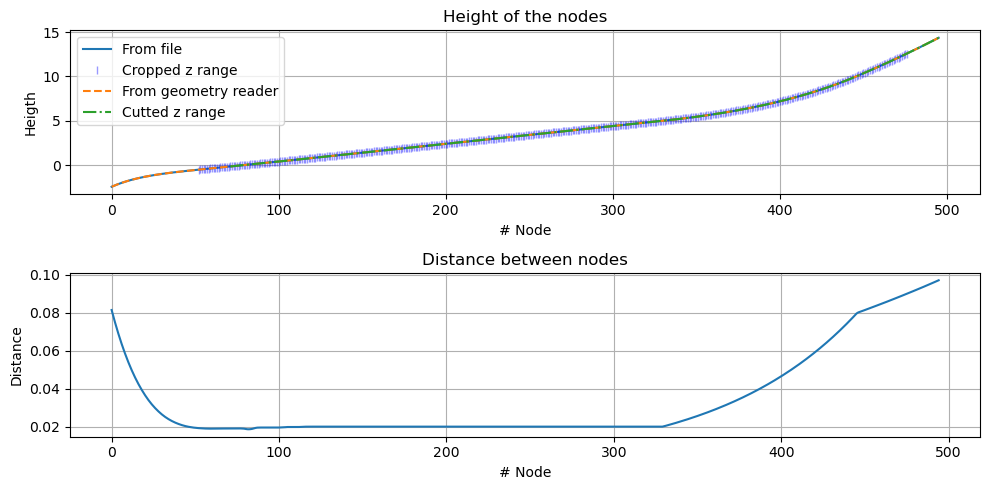

In [10]:
plt.figure(0,(10,5))
plt.subplot(2,1,1)
plt.plot(z_range, label='From file')
plt.plot(xz, z, '|b', alpha=0.4, label='Cropped z range')
plt.plot(z_geo/1e8, label='From geometry reader', linestyle='dashed')
plt.plot(xz_cutted, z_cutted, linestyle='dashdot', label='Cutted z range')
plt.legend()
plt.title('Height of the nodes')
plt.xlabel('# Node')
plt.ylabel('Heigth')
plt.grid()

plt.subplot(2,1,2)
plt.plot(z_steps)
plt.title('Distance between nodes')
plt.xlabel('# Node')
plt.ylabel('Distance')
plt.grid()

plt.tight_layout()
plt.show()

In [11]:
x, y = np.linspace(0, x_size, nx), np.linspace(0, y_size, ny)

In [12]:
print(x.shape, y.shape, z.shape)

(504,) (504,) (425,)


In [13]:
# save the x, y, z in a file called grid_bifrost
np.savez_compressed(f'{path_files}/en024048_hion/grid_bifrost.npz', x=x, y=y, z=z)
np.savez_compressed(f'{path_files}/en024048_hion/grid_bifrost_cutted.npz', x=x, y=y, z=z_cutted)